 # Clean textual,numerical inconsistencies, handling missing and duplicate values - IT24102948- Konara K. M. D. T

In [423]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import re
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [424]:
df = pd.read_csv('/content/Car details v3.csv')

In [425]:
display(df.head())

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [426]:
display(df.tail())

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
8123,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.5 kmpl,1197 CC,82.85 bhp,113.7Nm@ 4000rpm,5.0
8124,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.8 kmpl,1493 CC,110 bhp,"24@ 1,900-2,750(kgm@ rpm)",5.0
8125,Maruti Swift Dzire ZDi,2009,382000,120000,Diesel,Individual,Manual,First Owner,19.3 kmpl,1248 CC,73.9 bhp,190Nm@ 2000rpm,5.0
8126,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57 kmpl,1396 CC,70 bhp,140Nm@ 1800-3000rpm,5.0
8127,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57 kmpl,1396 CC,70 bhp,140Nm@ 1800-3000rpm,5.0


In [427]:
df.dtypes

,0
name,object
year,int64
selling_price,int64
km_driven,int64
fuel,object
seller_type,object
transmission,object
owner,object
mileage,object
engine,object


In [428]:
X = df.drop(columns=['selling_price'])  # Features
y = df['selling_price']  # Target

# Display top 5 rows
print("\nTop 5 rows of Features:")
print(X.head())
print("\nTop 5 rows of Target:")
print(y.head())


Top 5 rows of Features:
                           name  year  km_driven    fuel seller_type  \
0        Maruti Swift Dzire VDI  2014     145500  Diesel  Individual   
1  Skoda Rapid 1.5 TDI Ambition  2014     120000  Diesel  Individual   
2      Honda City 2017-2020 EXi  2006     140000  Petrol  Individual   
3     Hyundai i20 Sportz Diesel  2010     127000  Diesel  Individual   
4        Maruti Swift VXI BSIII  2007     120000  Petrol  Individual   

  transmission         owner     mileage   engine   max_power  \
0       Manual   First Owner   23.4 kmpl  1248 CC      74 bhp   
1       Manual  Second Owner  21.14 kmpl  1498 CC  103.52 bhp   
2       Manual   Third Owner   17.7 kmpl  1497 CC      78 bhp   
3       Manual   First Owner   23.0 kmpl  1396 CC      90 bhp   
4       Manual   First Owner   16.1 kmpl  1298 CC    88.2 bhp   

                     torque  seats  
0            190Nm@ 2000rpm    5.0  
1       250Nm@ 1500-2500rpm    5.0  
2     12.7@ 2,700(kgm@ rpm)    5.0  
3  

In [429]:
duplicate_rows_df = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)

number of duplicate rows:  (1202, 13)


In [430]:
df= df.drop_duplicates().reset_index(drop=True)

In [431]:
missing_values = df.isnull().sum()[df.columns]
print("Missing values:\n", missing_values)

if missing_values.sum() == 0:
    print("No missing values found.")

Missing values:
 name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          208
engine           208
max_power        205
torque           209
seats            208
dtype: int64


In [432]:
df.count()

,0
name,6926
year,6926
selling_price,6926
km_driven,6926
fuel,6926
seller_type,6926
transmission,6926
owner,6926
mileage,6718
engine,6718


In [433]:
# Drop torque coloumn
df.drop(columns=['torque'], inplace=True)

In [434]:
# Handle missing seat values with mode
numerical_cols = ['seats']
for col in numerical_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

In [435]:
# Handle missing mileage values with median
def clean_mileage_fixed(x):
    if pd.isna(x):
        return np.nan
    x = str(x).lower().strip()

    # Remove any letters, keep numeric part
    nums = re.findall(r"[\d.]+", x)
    if not nums:
        return np.nan
    value = float(nums[0])

    # Approx conversion if km/kg is mentioned
    if "kg" in x:
        value *= 1.35
    return value

df['mileage'] = df['mileage'].apply(clean_mileage_fixed)
df['mileage'] = df['mileage'].fillna(df['mileage'].median())


In [436]:
# Handle missing engine values with median

def clean_engine(x):
    if pd.isna(x):
        return np.nan
    # Extract numeric part
    nums = re.findall(r"[\d.]+", str(x))
    if not nums:
        return np.nan
    return float(nums[0])

df['engine'] = df['engine'].apply(clean_engine)
df['engine'] = df['engine'].fillna(df['engine'].median())


In [437]:
# Handle missing max power values with median

df['max_power'] = df['max_power'].apply(lambda x: str(x).replace(' bhp','').strip() if pd.notna(x) else np.nan)
df['max_power'] = pd.to_numeric(df['max_power'], errors='coerce')
df['max_power'] = df['max_power'].fillna(df['max_power'].median())

In [438]:
# Check missing values

print("Missing values after handling:")
print(df[['mileage','engine','max_power','seats']].isnull().sum())

Missing values after handling:
mileage      0
engine       0
max_power    0
seats        0
dtype: int64


In [439]:
display(df.head(5))

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0


In [440]:
display(df.tail(5))

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
6921,Maruti Wagon R VXI BS IV with ABS,2013,260000,50000,Petrol,Individual,Manual,Second Owner,18.90,998.0,67.10,5.0
6922,Hyundai i20 Magna 1.4 CRDi,2014,475000,80000,Diesel,Individual,Manual,Second Owner,22.54,1396.0,88.73,5.0
6923,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.50,1197.0,82.85,5.0
6924,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.80,1493.0,110.00,5.0
6925,Maruti Swift Dzire ZDi,2009,382000,120000,Diesel,Individual,Manual,First Owner,19.30,1248.0,73.90,5.0


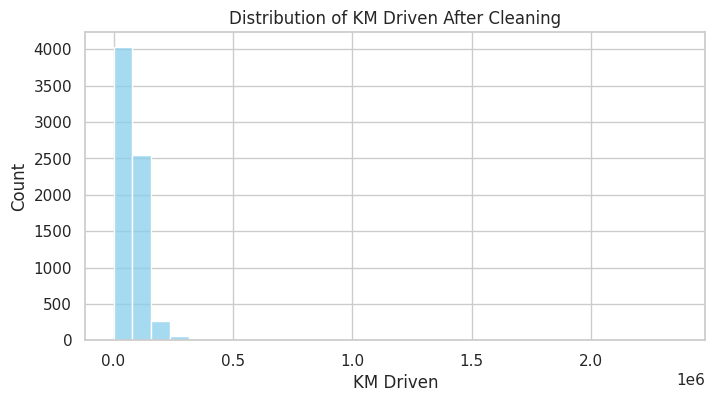

In [441]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")  # clean background

plt.figure(figsize=(8,4))
sns.histplot(df['km_driven'], bins=30,color='skyblue')
plt.title('Distribution of KM Driven After Cleaning')
plt.xlabel('KM Driven')
plt.ylabel('Count')
plt.show()


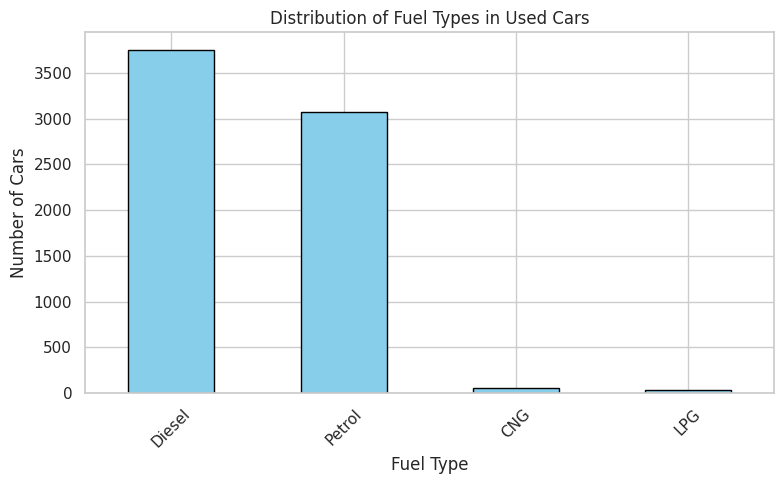

In [442]:
# Count fuel types
fuel_counts = df['fuel'].value_counts()

# Plot
plt.figure(figsize=(8, 5))
fuel_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Fuel Types in Used Cars')
plt.xlabel('Fuel Type')
plt.ylabel('Number of Cars')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("fuel_type_distribution.png")
plt.show()

## Categorical Encoding- IT24100136-Karunarathna M. M. G. A. S

In [443]:
# Identify categorical columns
categorical_cols = ['fuel', 'seller_type', 'transmission', 'owner']

In [444]:
# Check current unique values for reference
print("Unique values before encoding:")
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

Unique values before encoding:
fuel: ['Diesel' 'Petrol' 'LPG' 'CNG']
seller_type: ['Individual' 'Dealer' 'Trustmark Dealer']
transmission: ['Manual' 'Automatic']
owner: ['First Owner' 'Second Owner' 'Third Owner' 'Fourth & Above Owner'
 'Test Drive Car']


In [445]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

In [446]:
owner_mapping = {
    'Test Drive Car': 0,      # Best condition (lowest number)
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4 # Worst condition (highest number)
}

df['owner'] = df['owner'].map(owner_mapping)

In [447]:
# One-hot encoding for other categorical columns
ohe = OneHotEncoder(drop='first', sparse_output=False)
encoded_array = ohe.fit_transform(df[['fuel', 'seller_type', 'transmission']])

# Get feature names
feature_names = ohe.get_feature_names_out(['fuel', 'seller_type', 'transmission'])

# Create DataFrame with encoded features
encoded_df = pd.DataFrame(encoded_array, columns=feature_names, index=df.index)

# Drop original columns and concatenate with encoded ones
df = df.drop(['fuel', 'seller_type', 'transmission'], axis=1)
df = pd.concat([df, encoded_df], axis=1)

In [448]:
display(df.head())

,name,year,selling_price,km_driven,owner,mileage,engine,max_power,seats,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual
0,Maruti Swift Dzire VDI,2014,450000,145500,1,23.40,1248.0,74.00,5.0,1.0,0.0,0.0,1.0,0.0,1.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,2,21.14,1498.0,103.52,5.0,1.0,0.0,0.0,1.0,0.0,1.0
2,Honda City 2017-2020 EXi,2006,158000,140000,3,17.70,1497.0,78.00,5.0,0.0,0.0,1.0,1.0,0.0,1.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,1,23.00,1396.0,90.00,5.0,1.0,0.0,0.0,1.0,0.0,1.0
4,Maruti Swift VXI BSIII,2007,130000,120000,1,16.10,1298.0,88.20,5.0,0.0,0.0,1.0,1.0,0.0,1.0


In [449]:
display(df.tail())

,name,year,selling_price,km_driven,owner,mileage,engine,max_power,seats,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual
6921,Maruti Wagon R VXI BS IV with ABS,2013,260000,50000,2,18.90,998.0,67.10,5.0,0.0,0.0,1.0,1.0,0.0,1.0
6922,Hyundai i20 Magna 1.4 CRDi,2014,475000,80000,2,22.54,1396.0,88.73,5.0,1.0,0.0,0.0,1.0,0.0,1.0
6923,Hyundai i20 Magna,2013,320000,110000,1,18.50,1197.0,82.85,5.0,0.0,0.0,1.0,1.0,0.0,1.0
6924,Hyundai Verna CRDi SX,2007,135000,119000,4,16.80,1493.0,110.00,5.0,1.0,0.0,0.0,1.0,0.0,1.0
6925,Maruti Swift Dzire ZDi,2009,382000,120000,1,19.30,1248.0,73.90,5.0,1.0,0.0,0.0,1.0,0.0,1.0


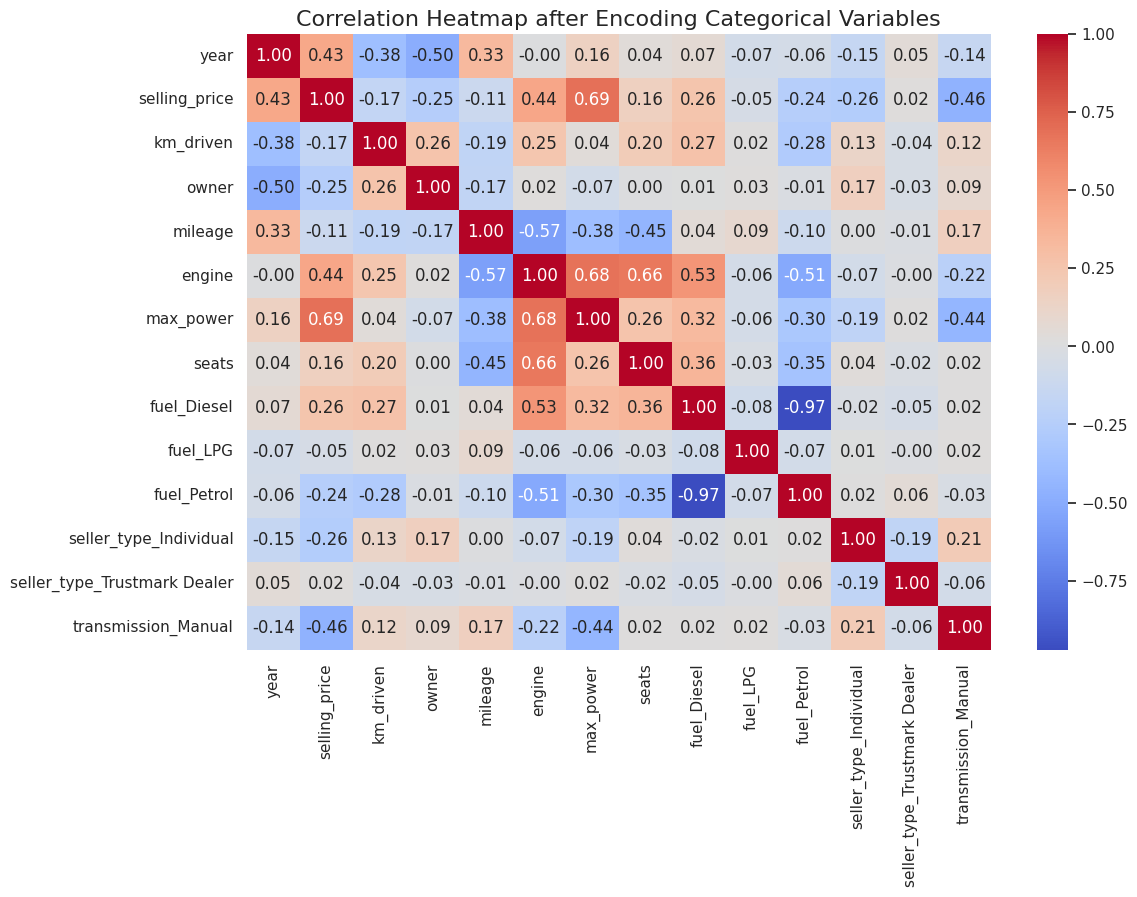

In [450]:
# Correlation heatmap for EDA

df_numeric = df.drop('name', axis=1)

plt.figure(figsize=(12,8))
sns.heatmap(df_numeric.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap after Encoding Categorical Variables", fontsize=16)
plt.show()

## REMOVE OUTLIERS-IT24100511-Rathnayake R. M. T. P

In [451]:
print("DataFrame shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Data types:\n", df.dtypes)

DataFrame shape: (6926, 15)
Columns: ['name', 'year', 'selling_price', 'km_driven', 'owner', 'mileage', 'engine', 'max_power', 'seats', 'fuel_Diesel', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Manual']
Data types:
 name                             object
year                              int64
selling_price                     int64
km_driven                         int64
owner                             int64
mileage                         float64
engine                          float64
max_power                       float64
seats                           float64
fuel_Diesel                     float64
fuel_LPG                        float64
fuel_Petrol                     float64
seller_type_Individual          float64
seller_type_Trustmark Dealer    float64
transmission_Manual             float64
dtype: object


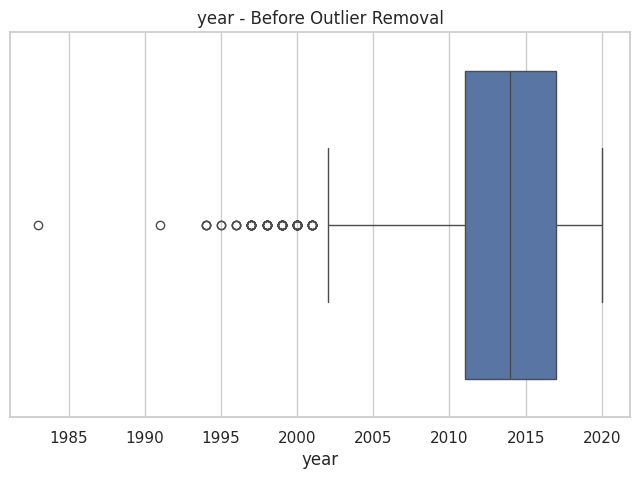

In [452]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['year'])
plt.title("year - Before Outlier Removal")
plt.show()

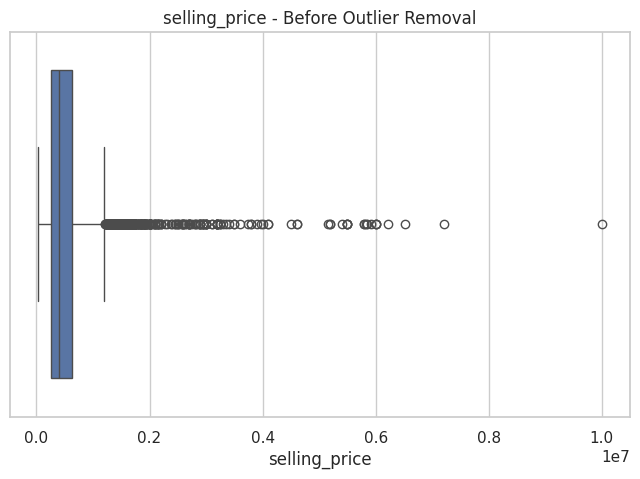

In [453]:

plt.figure(figsize=(8,5))
sns.boxplot(x=df['selling_price'])
plt.title("selling_price - Before Outlier Removal")
plt.show()

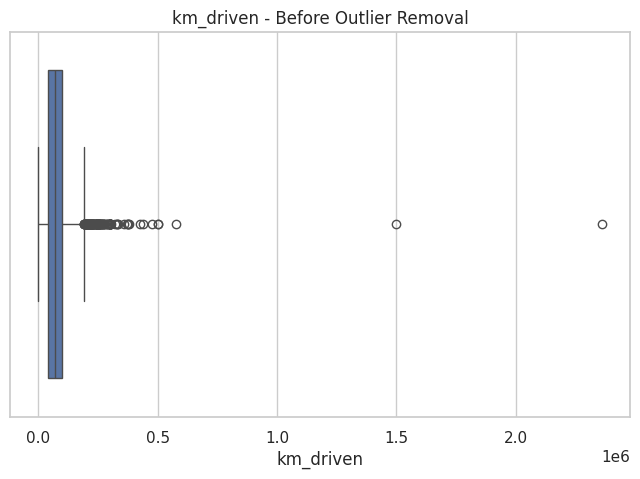

In [454]:

plt.figure(figsize=(8,5))
sns.boxplot(x=df['km_driven'])
plt.title("km_driven - Before Outlier Removal")
plt.show()

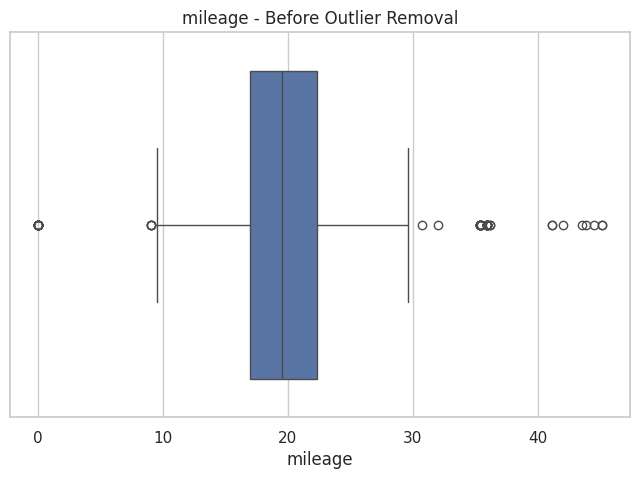

In [455]:

plt.figure(figsize=(8,5))
sns.boxplot(x=df['mileage'])
plt.title("mileage - Before Outlier Removal")
plt.show()

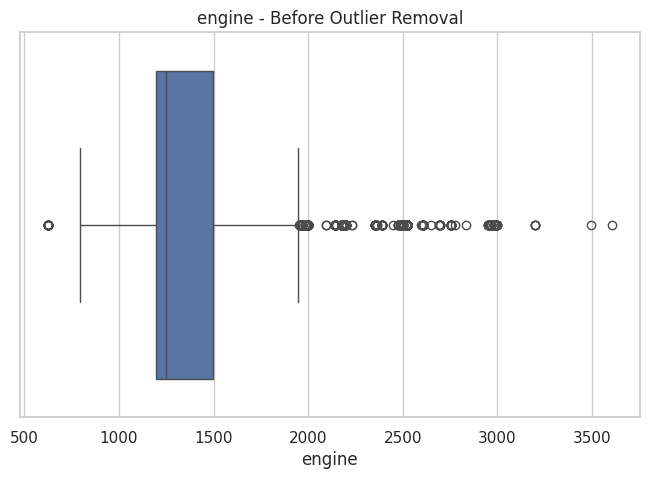

In [456]:

plt.figure(figsize=(8,5))
sns.boxplot(x=df['engine'])
plt.title("engine - Before Outlier Removal")
plt.show()

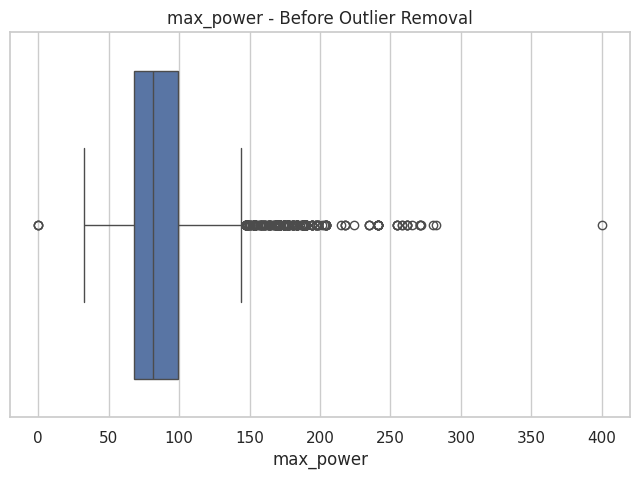

In [457]:

plt.figure(figsize=(8,5))
sns.boxplot(x=df['max_power'])
plt.title("max_power - Before Outlier Removal")
plt.show()


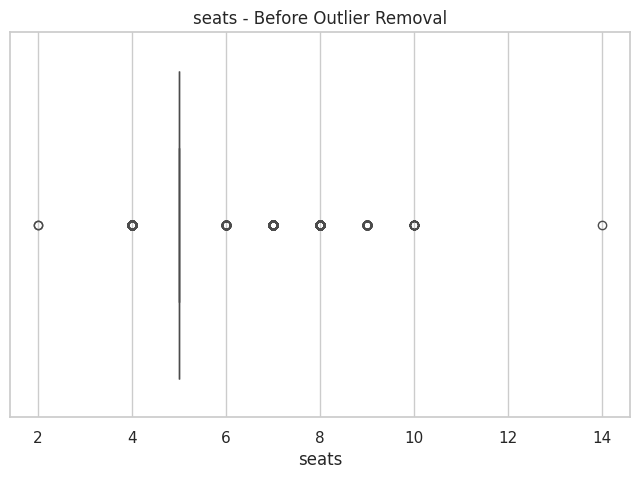

In [458]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['seats'])
plt.title("seats - Before Outlier Removal")
plt.show()

In [459]:
# Remove outliers from numerical FEATURES only (not from target variable 'selling_price')
numerical_features_to_clean = ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

print(f"Original dataset shape: {df.shape}")
original_size = len(df)

for col in numerical_features_to_clean:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers before removal
    outliers_count = len(df[(df[col] < lower_bound) | (df[col] > upper_bound)])
    print(f"{col}: {outliers_count} outliers detected")

    # Remove outliers from features only
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print(f"\nAfter outlier removal: {df.shape}")
print(f"Total rows removed: {original_size - len(df)}")
print(f"Percentage of data kept: {(len(df)/original_size)*100:.2f}%")

Original dataset shape: (6926, 15)
year: 77 outliers detected
km_driven: 162 outliers detected
mileage: 51 outliers detected
engine: 1103 outliers detected
max_power: 274 outliers detected
seats: 435 outliers detected

After outlier removal: (4824, 15)
Total rows removed: 2102
Percentage of data kept: 69.65%


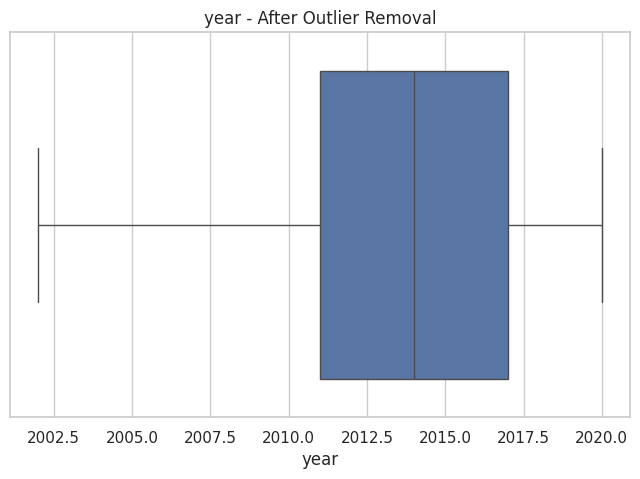

In [460]:
# Check distribution after outlier removal

plt.figure(figsize=(8,5))
sns.boxplot(x=df['year'])
plt.title("year - After Outlier Removal")
plt.show()

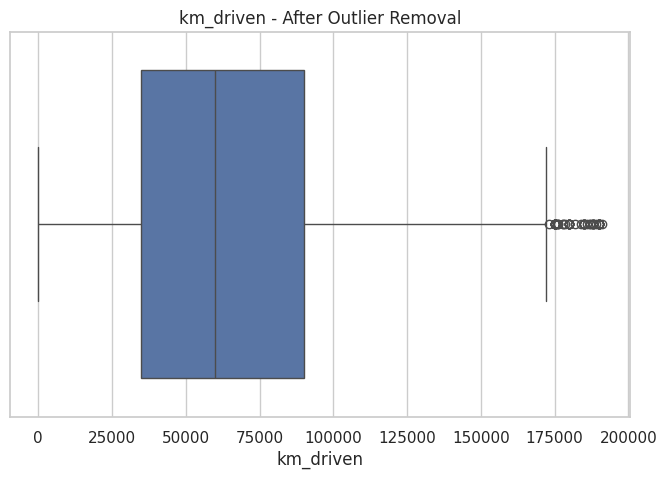

In [461]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['km_driven'])
plt.title("km_driven - After Outlier Removal")
plt.show()

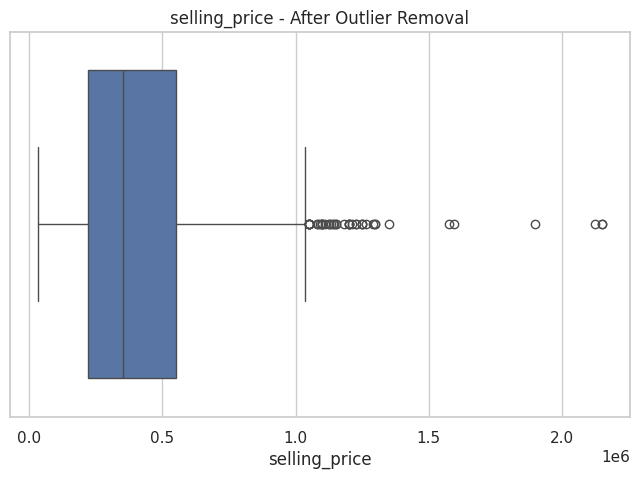

In [462]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['selling_price'])
plt.title("selling_price - After Outlier Removal")
plt.show()

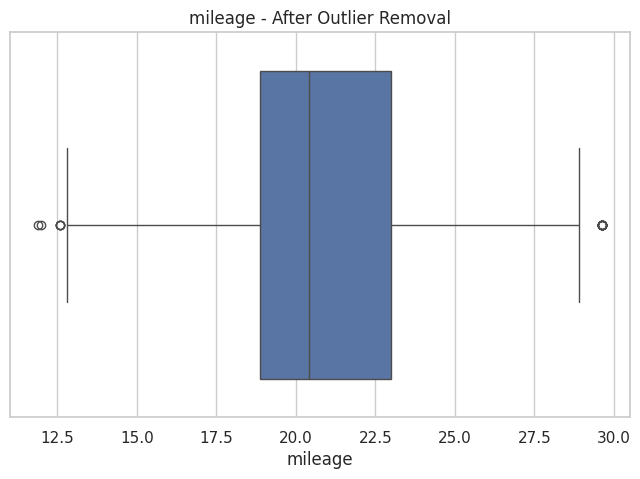

In [463]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['mileage'])
plt.title("mileage - After Outlier Removal")
plt.show()

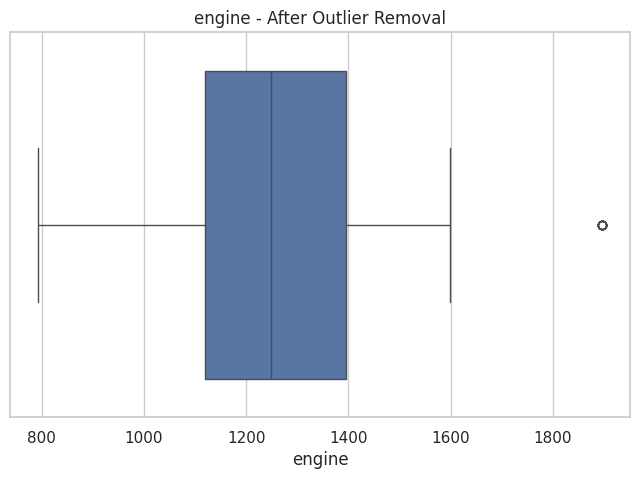

In [464]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['engine'])
plt.title("engine - After Outlier Removal")
plt.show()

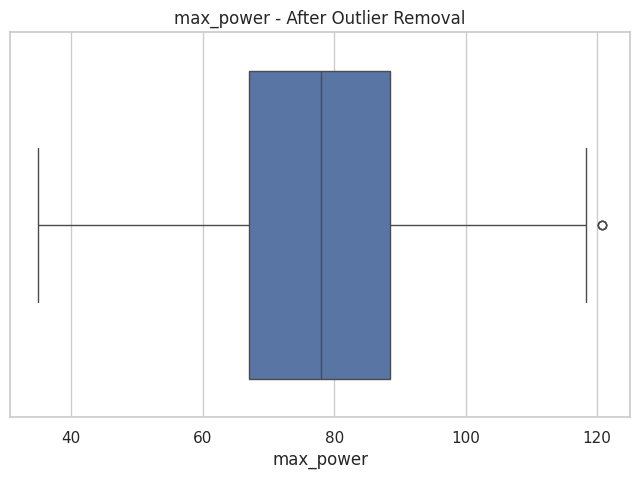

In [465]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['max_power'])
plt.title("max_power - After Outlier Removal")
plt.show()

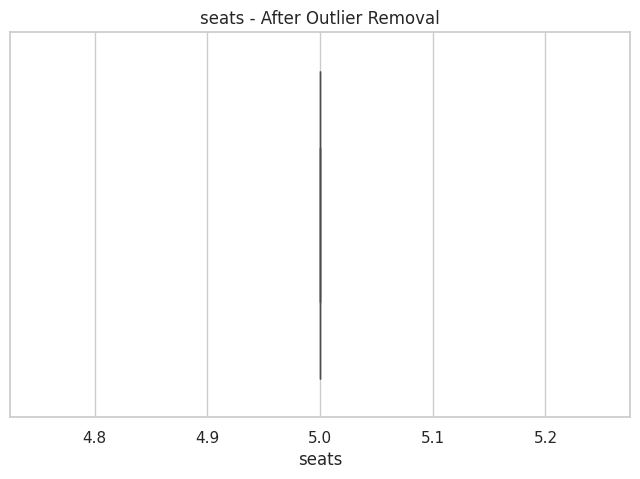

In [466]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['seats'])
plt.title("seats - After Outlier Removal")
plt.show()

## FEATURE ENGINEERING- IT24100971- Abeynayake D. A

In [467]:
display(df.head())

,name,year,selling_price,km_driven,owner,mileage,engine,max_power,seats,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual
0,Maruti Swift Dzire VDI,2014,450000,145500,1,23.40,1248.0,74.00,5.0,1.0,0.0,0.0,1.0,0.0,1.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,2,21.14,1498.0,103.52,5.0,1.0,0.0,0.0,1.0,0.0,1.0
2,Honda City 2017-2020 EXi,2006,158000,140000,3,17.70,1497.0,78.00,5.0,0.0,0.0,1.0,1.0,0.0,1.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,1,23.00,1396.0,90.00,5.0,1.0,0.0,0.0,1.0,0.0,1.0
4,Maruti Swift VXI BSIII,2007,130000,120000,1,16.10,1298.0,88.20,5.0,0.0,0.0,1.0,1.0,0.0,1.0


In [468]:
print("Data types:\n", df.dtypes)

Data types:
 name                             object
year                              int64
selling_price                     int64
km_driven                         int64
owner                             int64
mileage                         float64
engine                          float64
max_power                       float64
seats                           float64
fuel_Diesel                     float64
fuel_LPG                        float64
fuel_Petrol                     float64
seller_type_Individual          float64
seller_type_Trustmark Dealer    float64
transmission_Manual             float64
dtype: object


In [469]:
# CAR AGE (more meaningful than year)
from datetime import datetime
current_year = datetime.now().year
df['car_age'] = current_year - df['year']
print(df[['year','car_age']].head())

   year  car_age
0  2014       11
1  2014       11
2  2006       19
3  2010       15
4  2007       18


In [470]:
#  EXTRACT BRAND AND MODEL FROM NAME
df['brand'] = df['name'].str.split().str[0]
df['model'] = df['name'].str.split().str[1] # Second word usually model

In [471]:
# Top brands only (reduce dimensionality)
top_brands = df['brand'].value_counts().head(10).index
df['brand'] = df['brand'].apply(lambda x: x if x in top_brands else 'Other')

print(list(top_brands))

['Maruti', 'Hyundai', 'Tata', 'Ford', 'Honda', 'Renault', 'Volkswagen', 'Chevrolet', 'Toyota', 'Nissan']


In [472]:
# USAGE-RELATED FEATURES
df['km_per_year'] = df['km_driven'] / df['car_age'].replace(0, 1)  # Avoid division by zero
df['km_per_year'] = df['km_per_year'].fillna(df['km_per_year'].median())

In [473]:
# Categorize usage intensity
df['usage_intensity'] = pd.cut(df['km_per_year'],
                              bins=[0, 5000, 15000, 30000, float('inf')],
                              labels=['Low', 'Medium', 'High', 'Very High'])

In [474]:
# Performance ratios
df['specific_power'] = df['max_power'] / df['engine'].replace(0, 1)

In [475]:
# Interaction terms
df['age_km_interaction'] = df['car_age'] * df['km_driven']
df['mileage_power_interaction'] = df['mileage'] * df['max_power']

In [476]:
display(df.head())

,name,year,selling_price,km_driven,owner,mileage,engine,max_power,seats,fuel_Diesel,...,seller_type_Trustmark Dealer,transmission_Manual,car_age,brand,model,km_per_year,usage_intensity,specific_power,age_km_interaction,mileage_power_interaction
0,Maruti Swift Dzire VDI,2014,450000,145500,1,23.40,1248.0,74.00,5.0,1.0,...,0.0,1.0,11,Maruti,Swift,13227.272727,Medium,0.059295,1600500,1731.6000
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,2,21.14,1498.0,103.52,5.0,1.0,...,0.0,1.0,11,Other,Rapid,10909.090909,Medium,0.069105,1320000,2188.4128
2,Honda City 2017-2020 EXi,2006,158000,140000,3,17.70,1497.0,78.00,5.0,0.0,...,0.0,1.0,19,Honda,City,7368.421053,Medium,0.052104,2660000,1380.6000
3,Hyundai i20 Sportz Diesel,2010,225000,127000,1,23.00,1396.0,90.00,5.0,1.0,...,0.0,1.0,15,Hyundai,i20,8466.666667,Medium,0.064470,1905000,2070.0000
4,Maruti Swift VXI BSIII,2007,130000,120000,1,16.10,1298.0,88.20,5.0,0.0,...,0.0,1.0,18,Maruti,Swift,6666.666667,Medium,0.067951,2160000,1420.0200


In [477]:
print("DataFrame shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Data types:\n", df.dtypes)

DataFrame shape: (4824, 23)
Columns: ['name', 'year', 'selling_price', 'km_driven', 'owner', 'mileage', 'engine', 'max_power', 'seats', 'fuel_Diesel', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Manual', 'car_age', 'brand', 'model', 'km_per_year', 'usage_intensity', 'specific_power', 'age_km_interaction', 'mileage_power_interaction']
Data types:
 name                              object
year                               int64
selling_price                      int64
km_driven                          int64
owner                              int64
mileage                          float64
engine                           float64
max_power                        float64
seats                            float64
fuel_Diesel                      float64
fuel_LPG                         float64
fuel_Petrol                      float64
seller_type_Individual           float64
seller_type_Trustmark Dealer     float64
transmission_Manual   

In [478]:
# Ordinal encode usage_intensity
ordinal_map = {'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4}
df['usage_intensity'] = df['usage_intensity'].map(ordinal_map).astype(int)

# One-hot encode brand
df = pd.get_dummies(df, columns=['brand'], drop_first=True, dtype=int)

# Check final dataset
print(f"Final dataset shape: {df.shape}")
print(f"Total features: {len(df.columns)}")

Final dataset shape: (4824, 32)
Total features: 32


In [479]:
print("DataFrame shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Data types:\n", df.dtypes)

DataFrame shape: (4824, 32)
Columns: ['name', 'year', 'selling_price', 'km_driven', 'owner', 'mileage', 'engine', 'max_power', 'seats', 'fuel_Diesel', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Manual', 'car_age', 'model', 'km_per_year', 'usage_intensity', 'specific_power', 'age_km_interaction', 'mileage_power_interaction', 'brand_Ford', 'brand_Honda', 'brand_Hyundai', 'brand_Maruti', 'brand_Nissan', 'brand_Other', 'brand_Renault', 'brand_Tata', 'brand_Toyota', 'brand_Volkswagen']
Data types:
 name                             object
year                              int64
selling_price                     int64
km_driven                         int64
owner                             int64
mileage                         float64
engine                          float64
max_power                       float64
seats                           float64
fuel_Diesel                     float64
fuel_LPG                        float64
fuel_

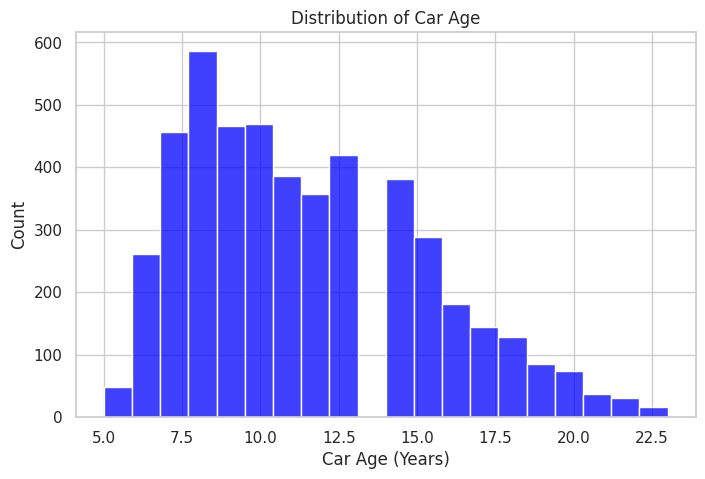

In [480]:
#Distribution of Car Age
plt.figure(figsize=(8,5))
sns.histplot(df['car_age'], bins=20,color="blue")
plt.title("Distribution of Car Age")
plt.xlabel("Car Age (Years)")
plt.show()

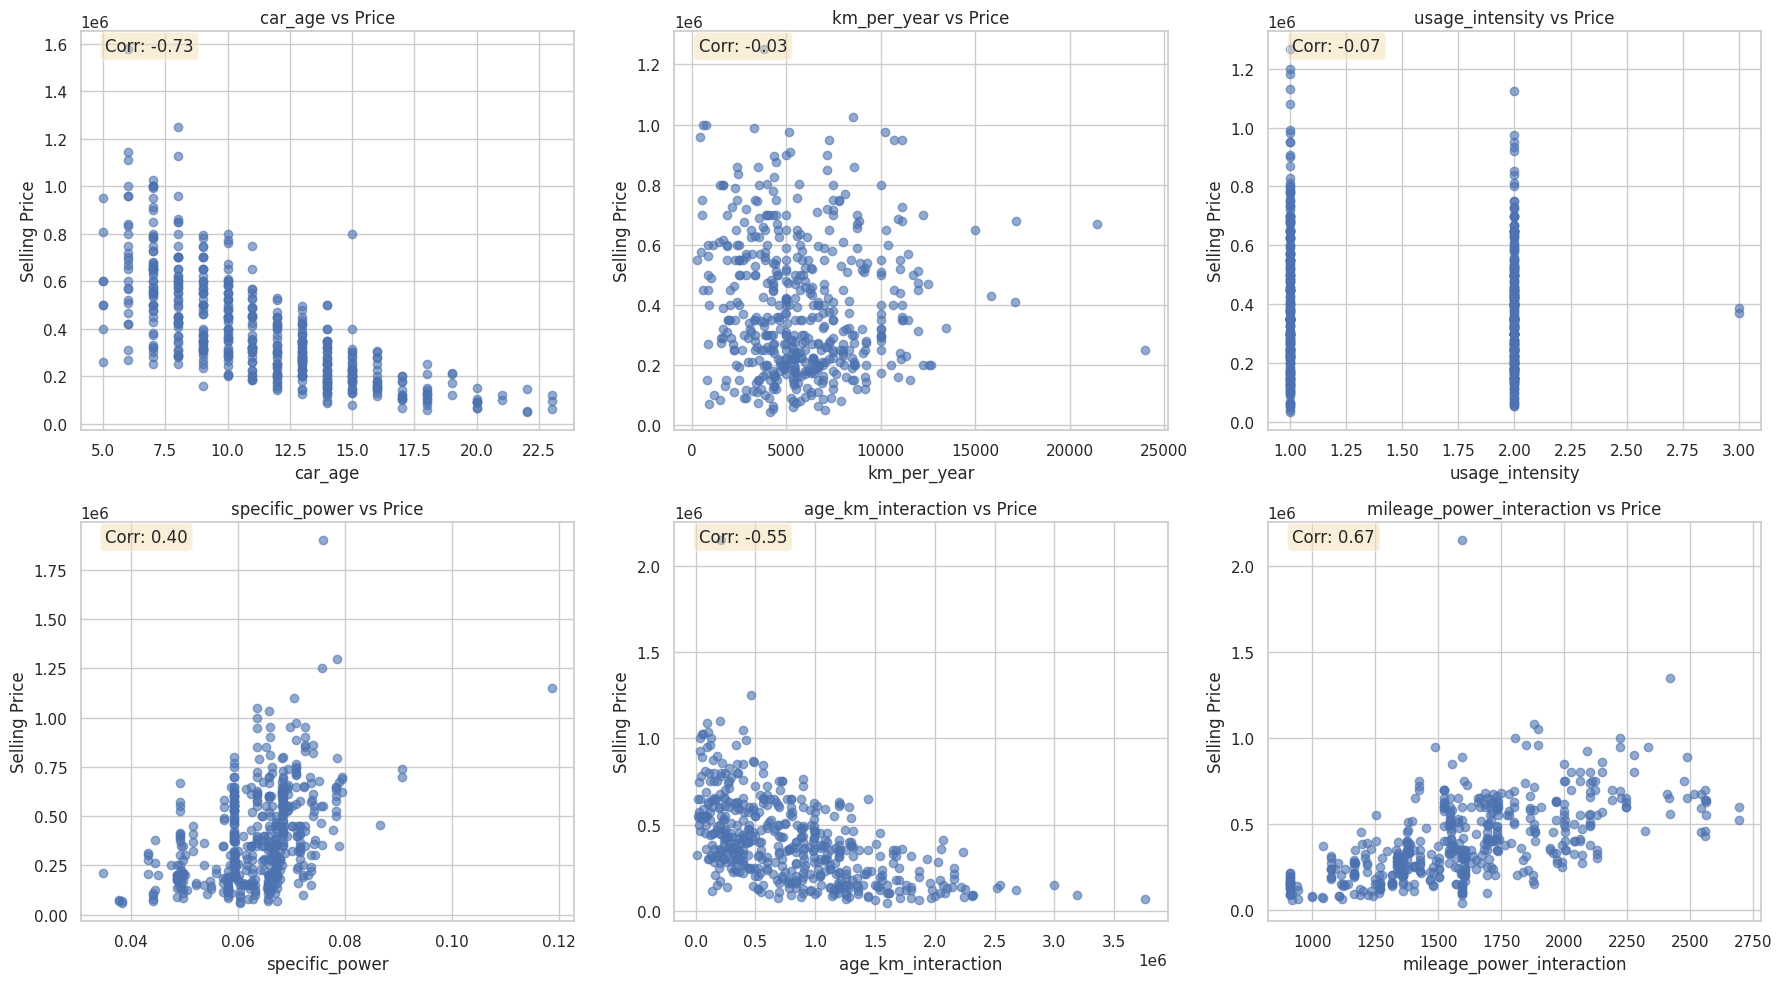

In [481]:
engineered_features = ['car_age', 'km_per_year', 'usage_intensity', 'specific_power',
                      'age_km_interaction', 'mileage_power_interaction']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, feat in enumerate(engineered_features):
    if i < len(axes):
        # Scatter plot with price
        df_sample = df.sample(min(500, len(df)))
        axes[i].scatter(df_sample[feat], df_sample['selling_price'], alpha=0.6)
        axes[i].set_title(f'{feat} vs Price')
        axes[i].set_xlabel(feat)
        axes[i].set_ylabel('Selling Price')

        corr = df[[feat, 'selling_price']].corr().iloc[0,1]
        axes[i].text(0.05, 0.95, f'Corr: {corr:.2f}', transform=axes[i].transAxes,
                    bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## FEATURE SELECTION- IT24101405-Rushdi M. R

In [482]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

In [483]:
#Debugging & Checking Non-Numeric Columns

print("Checking dataset for non-numeric columns...\n")
non_numeric_cols = df.select_dtypes(include=['object', 'category']).columns

print("All non-numeric columns found:", list(non_numeric_cols))
print("All columns in dataset:", list(df.columns))
print("\nData types of all columns:")
print(df.dtypes)

Checking dataset for non-numeric columns...

All non-numeric columns found: ['name', 'model']
All columns in dataset: ['name', 'year', 'selling_price', 'km_driven', 'owner', 'mileage', 'engine', 'max_power', 'seats', 'fuel_Diesel', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Manual', 'car_age', 'model', 'km_per_year', 'usage_intensity', 'specific_power', 'age_km_interaction', 'mileage_power_interaction', 'brand_Ford', 'brand_Honda', 'brand_Hyundai', 'brand_Maruti', 'brand_Nissan', 'brand_Other', 'brand_Renault', 'brand_Tata', 'brand_Toyota', 'brand_Volkswagen']

Data types of all columns:
name                             object
year                              int64
selling_price                     int64
km_driven                         int64
owner                             int64
mileage                         float64
engine                          float64
max_power                       float64
seats                        

In [484]:
# Target variable
y = df["selling_price"]

# Features (remove target + raw text if still there)
X = df.drop(columns=["selling_price", "name", "model"], errors="ignore")

print("Features shape after dropping unwanted columns:", X.shape)


Features shape after dropping unwanted columns: (4824, 29)


In [485]:
display(X.head())
print("Columns in X:", X.columns.tolist())

,year,km_driven,owner,mileage,engine,max_power,seats,fuel_Diesel,fuel_LPG,fuel_Petrol,...,brand_Ford,brand_Honda,brand_Hyundai,brand_Maruti,brand_Nissan,brand_Other,brand_Renault,brand_Tata,brand_Toyota,brand_Volkswagen
0,2014,145500,1,23.40,1248.0,74.00,5.0,1.0,0.0,0.0,...,0,0,0,1,0,0,0,0,0,0
1,2014,120000,2,21.14,1498.0,103.52,5.0,1.0,0.0,0.0,...,0,0,0,0,0,1,0,0,0,0
2,2006,140000,3,17.70,1497.0,78.00,5.0,0.0,0.0,1.0,...,0,1,0,0,0,0,0,0,0,0
3,2010,127000,1,23.00,1396.0,90.00,5.0,1.0,0.0,0.0,...,0,0,1,0,0,0,0,0,0,0
4,2007,120000,1,16.10,1298.0,88.20,5.0,0.0,0.0,1.0,...,0,0,0,1,0,0,0,0,0,0


Columns in X: ['year', 'km_driven', 'owner', 'mileage', 'engine', 'max_power', 'seats', 'fuel_Diesel', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Manual', 'car_age', 'km_per_year', 'usage_intensity', 'specific_power', 'age_km_interaction', 'mileage_power_interaction', 'brand_Ford', 'brand_Honda', 'brand_Hyundai', 'brand_Maruti', 'brand_Nissan', 'brand_Other', 'brand_Renault', 'brand_Tata', 'brand_Toyota', 'brand_Volkswagen']


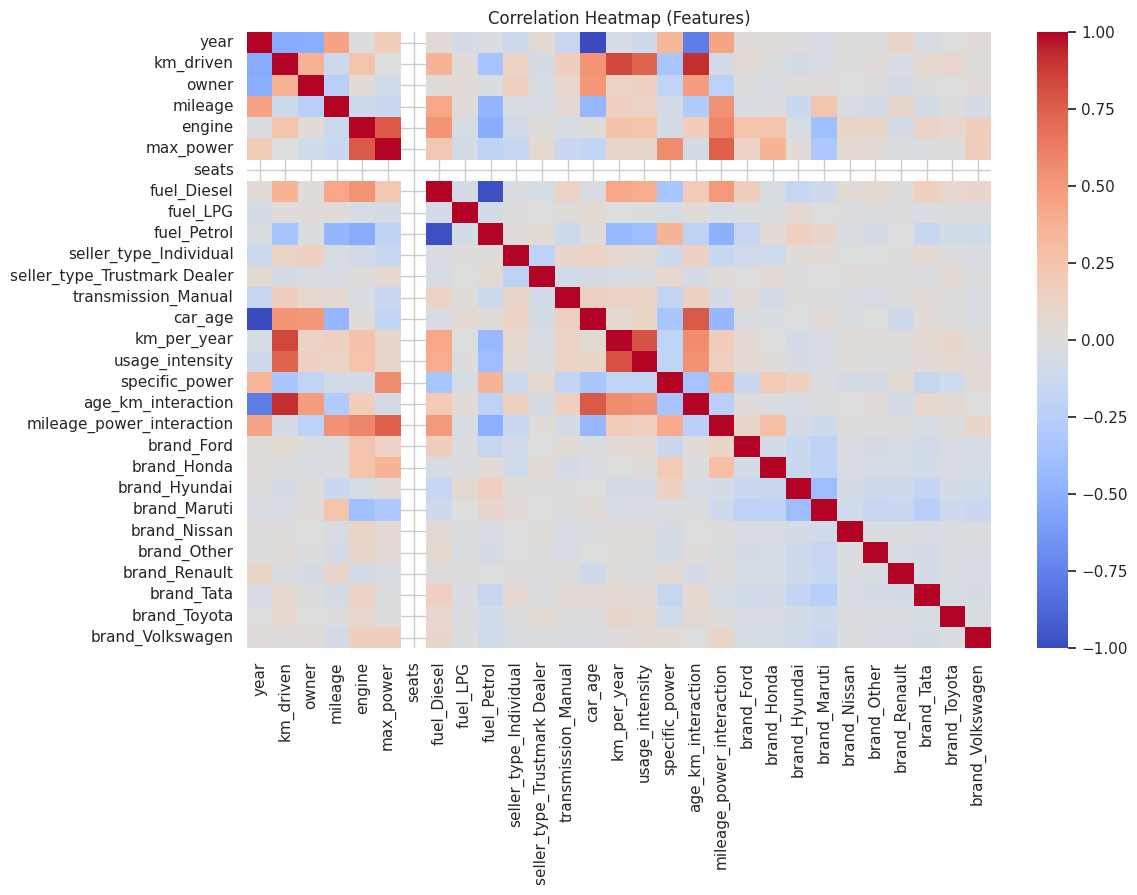

In [486]:
# Select only numeric columns from X
X_numeric = X.select_dtypes(include=[np.number])
#Correlation Heatmap
plt.figure(figsize=(12,8))
corr_matrix = X_numeric.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap (Features)")
plt.show()

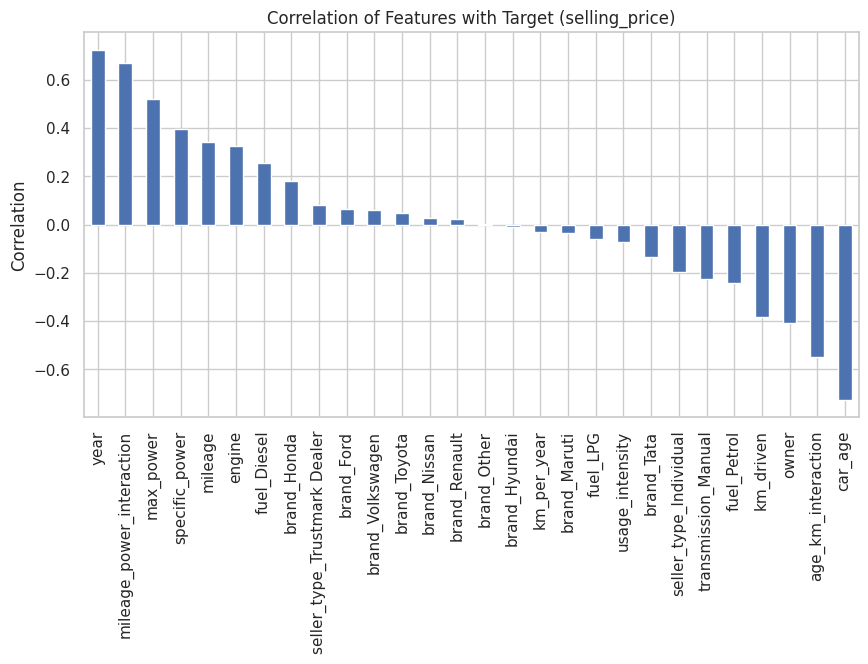


Correlation with selling_price:
 year                            0.725238
mileage_power_interaction       0.668980
max_power                       0.520643
specific_power                  0.397727
mileage                         0.343260
engine                          0.325420
fuel_Diesel                     0.254951
brand_Honda                     0.181904
seller_type_Trustmark Dealer    0.082648
brand_Ford                      0.065408
brand_Volkswagen                0.058822
brand_Toyota                    0.048969
brand_Nissan                    0.029008
brand_Renault                   0.021691
brand_Other                     0.004016
brand_Hyundai                  -0.008262
km_per_year                    -0.031558
brand_Maruti                   -0.032772
fuel_LPG                       -0.060775
usage_intensity                -0.069871
brand_Tata                     -0.135375
seller_type_Individual         -0.195358
transmission_Manual            -0.223642
fuel_Petrol            

In [487]:
# Drop constant features (zero variance) before correlation
X_numeric = X_numeric.loc[:, X_numeric.nunique() > 1]
# Correlation with target
corr_target = X_numeric.corrwith(y).sort_values(ascending=False)
plt.figure(figsize=(10,5))
corr_target.plot(kind='bar')
plt.title("Correlation of Features with Target (selling_price)")
plt.ylabel("Correlation")
plt.show()

print("\nCorrelation with selling_price:\n", corr_target)

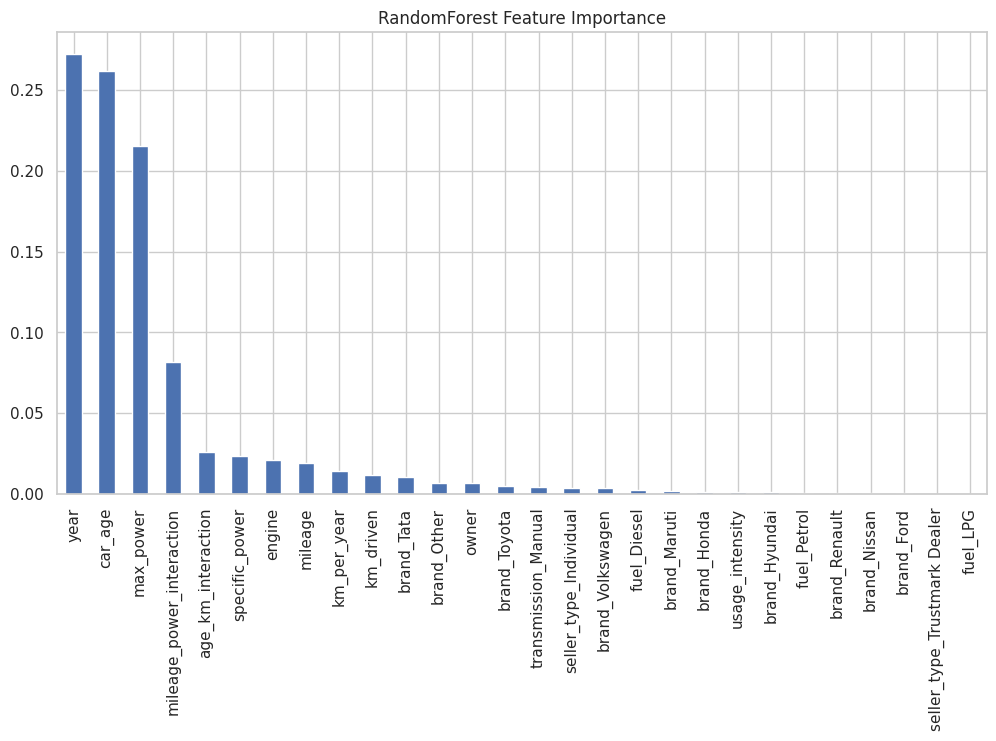


Features with very low importance (<0.005): ['fuel_Diesel', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Manual', 'usage_intensity', 'brand_Ford', 'brand_Honda', 'brand_Hyundai', 'brand_Maruti', 'brand_Nissan', 'brand_Renault', 'brand_Toyota', 'brand_Volkswagen']


In [488]:
#RandomForest Feature Importance
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_numeric, y)

importances = pd.Series(rf_model.feature_importances_, index=X_numeric.columns)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(12,6))
plt.title("RandomForest Feature Importance")
plt.show()

print("\nFeatures with very low importance (<0.005):",
      importances[importances < 0.005].index.tolist())

In [489]:
#RFE (Wrapper Method)
lr = LinearRegression()
n_features = min(10, X_numeric.shape[1])  # select top 10 or fewer if <10
rfe = RFE(lr, n_features_to_select=n_features)
rfe.fit(X_numeric, y)

selected_features_rfe = X_numeric.columns[rfe.support_]
print(f"\nTop {n_features} features selected by RFE:", selected_features_rfe.tolist())


Top 10 features selected by RFE: ['fuel_Diesel', 'seller_type_Trustmark Dealer', 'transmission_Manual', 'specific_power', 'brand_Ford', 'brand_Honda', 'brand_Hyundai', 'brand_Maruti', 'brand_Nissan', 'brand_Toyota']


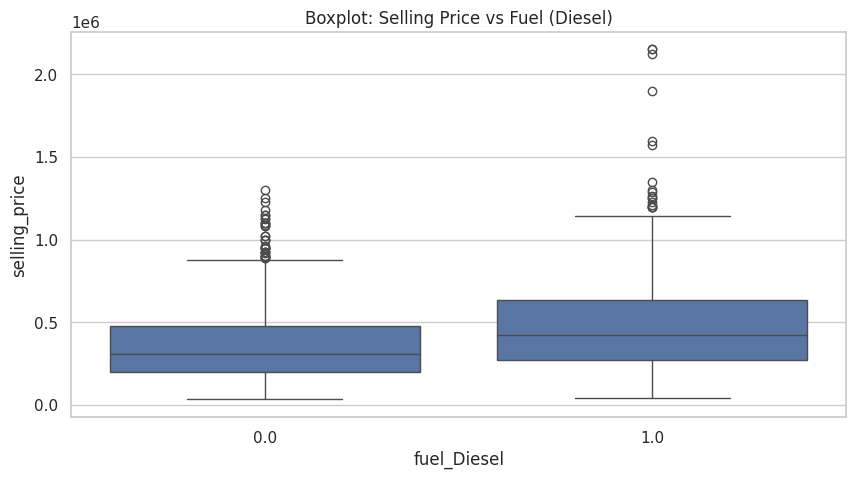

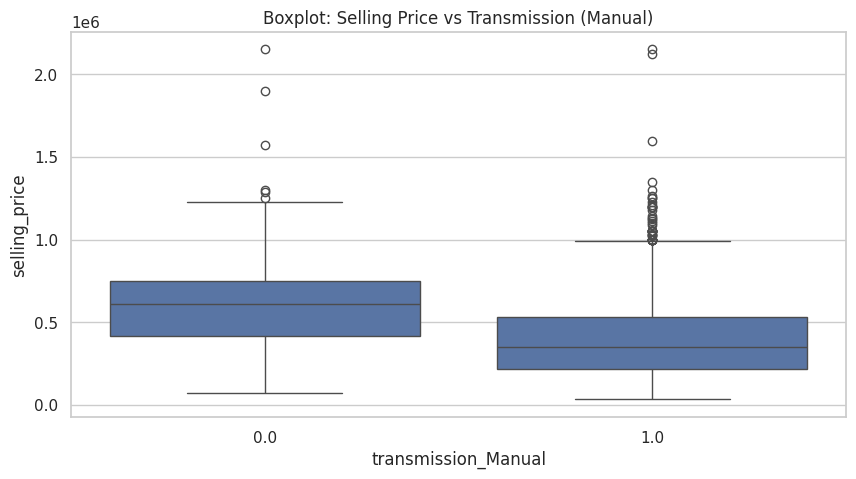

In [490]:
#Boxplots
# -------------------------------
plt.figure(figsize=(10,5))
sns.boxplot(x=df['fuel_Diesel'], y=df['selling_price'])
plt.title("Boxplot: Selling Price vs Fuel (Diesel)")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x=df['transmission_Manual'], y=df['selling_price'])
plt.title("Boxplot: Selling Price vs Transmission (Manual)")
plt.show()

Correlation between 'year' and 'car_age':
         year  car_age
year      1.0     -1.0
car_age  -1.0      1.0

VIF values for year and car_age:
   Feature       VIF
0     year  9.821729
1  car_age  9.821729


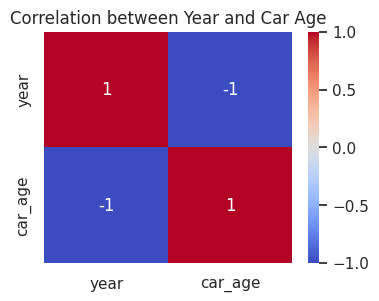

In [491]:
brand_cols = [col for col in X_numeric.columns if col.startswith('brand_')]

final_features = list(
    set(corr_target[abs(corr_target) >= 0.05].index) |
    set(importances[importances >= 0.005].index) |
    set(selected_features_rfe) |
    set(brand_cols)   #ensure all brand columns are kept
)
#Proof that 'year' is redundant since 'car_age' is already created

if 'year' in df.columns and 'car_age' in df.columns:
    print("Correlation between 'year' and 'car_age':")
    print(df[['year', 'car_age']].corr())

    from statsmodels.stats.outliers_influence import variance_inflation_factor
    X_vif = df[['year', 'car_age']].dropna()
    vif_data = pd.DataFrame()
    vif_data['Feature'] = X_vif.columns
    vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
    print("\nVIF values for year and car_age:")
    print(vif_data)

# Drop 'year' if its infinal features
if 'year' in final_features:
    final_features.remove('year')

plt.figure(figsize=(4,3))
sns.heatmap(df[['year','car_age']].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation between Year and Car Age")
plt.show()

In [492]:
print("\nFinal selected features for modeling:", final_features)

X_final = X_numeric[final_features]
print(f"\nShape of X_final: {X_final.shape}")
display(X_final.head())


Final selected features for modeling: ['brand_Ford', 'brand_Volkswagen', 'car_age', 'brand_Toyota', 'usage_intensity', 'owner', 'brand_Other', 'brand_Honda', 'mileage_power_interaction', 'engine', 'mileage', 'transmission_Manual', 'km_per_year', 'brand_Nissan', 'km_driven', 'max_power', 'seller_type_Trustmark Dealer', 'brand_Hyundai', 'brand_Renault', 'fuel_Diesel', 'brand_Maruti', 'fuel_Petrol', 'age_km_interaction', 'brand_Tata', 'fuel_LPG', 'specific_power', 'seller_type_Individual']

Shape of X_final: (4824, 27)


,brand_Ford,brand_Volkswagen,car_age,brand_Toyota,usage_intensity,owner,brand_Other,brand_Honda,mileage_power_interaction,engine,...,brand_Hyundai,brand_Renault,fuel_Diesel,brand_Maruti,fuel_Petrol,age_km_interaction,brand_Tata,fuel_LPG,specific_power,seller_type_Individual
0,0,0,11,0,2,1,0,0,1731.6000,1248.0,...,0,0,1.0,1,0.0,1600500,0,0.0,0.059295,1.0
1,0,0,11,0,2,2,1,0,2188.4128,1498.0,...,0,0,1.0,0,0.0,1320000,0,0.0,0.069105,1.0
2,0,0,19,0,2,3,0,1,1380.6000,1497.0,...,0,0,0.0,0,1.0,2660000,0,0.0,0.052104,1.0
3,0,0,15,0,2,1,0,0,2070.0000,1396.0,...,1,0,1.0,0,0.0,1905000,0,0.0,0.064470,1.0
4,0,0,18,0,2,1,0,0,1420.0200,1298.0,...,0,0,0.0,1,1.0,2160000,0,0.0,0.067951,1.0


In [493]:
import os

# Create the directory if it doesn't exist
output_dir = 'data/processed'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")

#Save final dataset after feature selection
df_final = pd.concat([X_final, y], axis=1)

df_final.to_csv(os.path.join(output_dir, "dataset_after_feature_selection.csv"), index=False)

print("\nFinal dataset saved")
print("Shape:", df_final.shape)
print("Columns:", df_final.columns.tolist())
display(df_final.head())


Final dataset saved
Shape: (4824, 28)
Columns: ['brand_Ford', 'brand_Volkswagen', 'car_age', 'brand_Toyota', 'usage_intensity', 'owner', 'brand_Other', 'brand_Honda', 'mileage_power_interaction', 'engine', 'mileage', 'transmission_Manual', 'km_per_year', 'brand_Nissan', 'km_driven', 'max_power', 'seller_type_Trustmark Dealer', 'brand_Hyundai', 'brand_Renault', 'fuel_Diesel', 'brand_Maruti', 'fuel_Petrol', 'age_km_interaction', 'brand_Tata', 'fuel_LPG', 'specific_power', 'seller_type_Individual', 'selling_price']


,brand_Ford,brand_Volkswagen,car_age,brand_Toyota,usage_intensity,owner,brand_Other,brand_Honda,mileage_power_interaction,engine,...,brand_Renault,fuel_Diesel,brand_Maruti,fuel_Petrol,age_km_interaction,brand_Tata,fuel_LPG,specific_power,seller_type_Individual,selling_price
0,0,0,11,0,2,1,0,0,1731.6000,1248.0,...,0,1.0,1,0.0,1600500,0,0.0,0.059295,1.0,450000
1,0,0,11,0,2,2,1,0,2188.4128,1498.0,...,0,1.0,0,0.0,1320000,0,0.0,0.069105,1.0,370000
2,0,0,19,0,2,3,0,1,1380.6000,1497.0,...,0,0.0,0,1.0,2660000,0,0.0,0.052104,1.0,158000
3,0,0,15,0,2,1,0,0,2070.0000,1396.0,...,0,1.0,0,0.0,1905000,0,0.0,0.064470,1.0,225000
4,0,0,18,0,2,1,0,0,1420.0200,1298.0,...,0,0.0,1,1.0,2160000,0,0.0,0.067951,1.0,130000


## SCALING- IT24102141-  Dissanayake H.M.C.P

In [494]:
df_final = pd.read_csv("data/processed/dataset_after_feature_selection.csv")

In [495]:
print(f"Shape: {df_final.shape}")
print(f"Columns: {df_final.columns.tolist()}")
print("Data types:\n", df_final.dtypes)

Shape: (4824, 28)
Columns: ['brand_Ford', 'brand_Volkswagen', 'car_age', 'brand_Toyota', 'usage_intensity', 'owner', 'brand_Other', 'brand_Honda', 'mileage_power_interaction', 'engine', 'mileage', 'transmission_Manual', 'km_per_year', 'brand_Nissan', 'km_driven', 'max_power', 'seller_type_Trustmark Dealer', 'brand_Hyundai', 'brand_Renault', 'fuel_Diesel', 'brand_Maruti', 'fuel_Petrol', 'age_km_interaction', 'brand_Tata', 'fuel_LPG', 'specific_power', 'seller_type_Individual', 'selling_price']
Data types:
 brand_Ford                        int64
brand_Volkswagen                  int64
car_age                           int64
brand_Toyota                      int64
usage_intensity                   int64
owner                             int64
brand_Other                       int64
brand_Honda                       int64
mileage_power_interaction       float64
engine                          float64
mileage                         float64
transmission_Manual             float64
km_per_ye

In [496]:
numerical_features = [
    'age_km_interaction',
    'mileage_power_interaction',
    'mileage',
    'specific_power',
    'engine',
    'max_power',
    'km_per_year',
    'car_age',
    'km_driven'
]

In [504]:
# Separate X and y first
X = df_final.drop('selling_price', axis=1)  # Features
y = df_final['selling_price']               # Target

In [505]:
# Scale only the features (X)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numerical_features] = scaler.fit_transform(X[numerical_features])

In [506]:
# Check before and after scaling
print("\nSCALING VERIFICATION ")
for feature in numerical_features[:3]:  # Check first 3 features
    print(f"\n{feature}:")
    print(f"  Before - Mean: {X[feature].mean():.2f}, Std: {X[feature].std():.2f}")
    print(f"  After  - Mean: {X_scaled[feature].mean():.2f}, Std: {X_scaled[feature].std():.2f}")

# Check the final result
print(f"\nFinal X_scaled shape: {X_scaled.shape}")
print("\nFirst 5 rows after scaling:")
print(X_scaled.head())


SCALING VERIFICATION 

age_km_interaction:
  Before - Mean: 832642.80, Std: 640163.18
  After  - Mean: -0.00, Std: 1.00

mileage_power_interaction:
  Before - Mean: 1615.32, Std: 383.82
  After  - Mean: -0.00, Std: 1.00

mileage:
  Before - Mean: 20.85, Std: 3.15
  After  - Mean: -0.00, Std: 1.00

Final X_scaled shape: (4824, 27)

First 5 rows after scaling:
   brand_Ford  brand_Volkswagen   car_age  brand_Toyota  usage_intensity  \
0           0                 0 -0.099796             0                2   
1           0                 0 -0.099796             0                2   
2           0                 0  2.001310             0                2   
3           0                 0  0.950757             0                2   
4           0                 0  1.738671             0                2   

   owner  brand_Other  brand_Honda  mileage_power_interaction    engine  ...  \
0      1            0            0                   0.302987  0.138682  ...   
1      2            1

In [507]:
import os

# Create the 'models' directory if it doesn't exist
if not os.path.exists('models'):
    os.makedirs('models')
    print("Created 'models' directory.")
else:
    print("'models' directory already exists.")

'models' directory already exists.


In [508]:
# Combine scaled features with target for saving
df_scaled = X_scaled.copy()
df_scaled['selling_price'] = y

# Save the preprocessed dataset
df_scaled.to_csv('/content/models/df_processed.csv', index=False)

print("\nProcessed dataset")



Processed dataset


In [509]:
# Save the scaler for future use
import joblib
joblib.dump(scaler, 'models/scaler.pkl')

print("Scaled dataset and scaler saved successfully!")

Scaled dataset and scaler saved successfully!


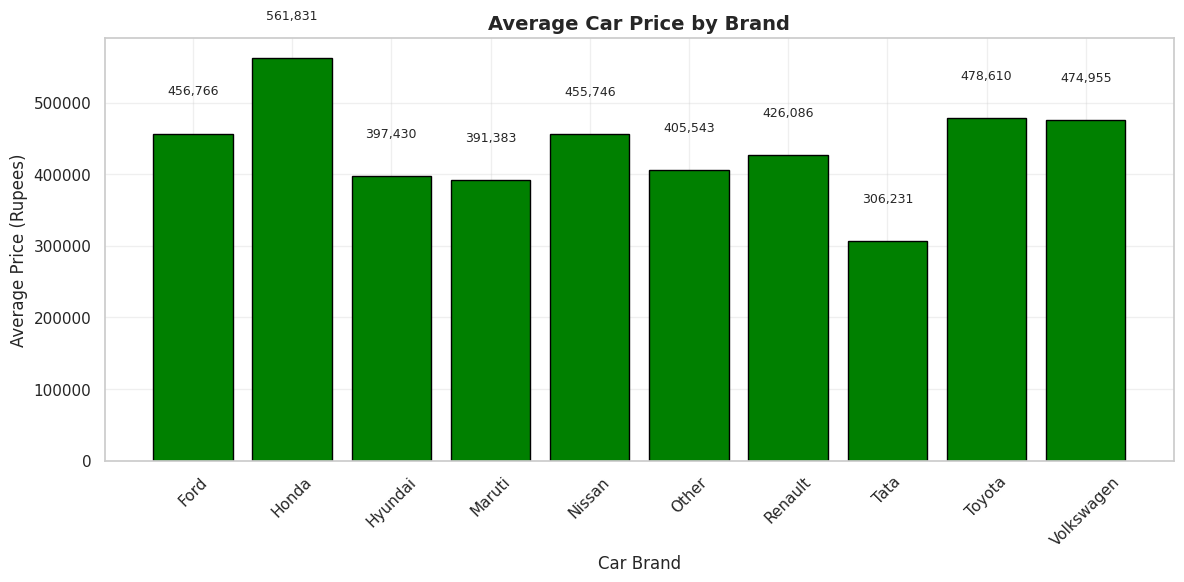

In [510]:
import matplotlib.pyplot as plt

# Calculate average price for each brand
brand_columns = [col for col in df.columns if 'brand_' in col]
brand_prices = {}

for brand in brand_columns:
    brand_prices[brand.replace('brand_', '')] = df[df[brand] == 1]['selling_price'].mean()

# Create bar chart
plt.figure(figsize=(12, 6))
brands = list(brand_prices.keys())
prices = list(brand_prices.values())

plt.bar(brands, prices, color='green', edgecolor='black')
plt.xlabel('Car Brand')
plt.ylabel('Average Price (Rupees)')
plt.title('Average Car Price by Brand', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Add value labels on bars
for i, price in enumerate(prices):
    plt.text(i, price + 50000, f'{price:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()